# 9.3.1 从相对熵到均值场更新

## 学习目标与先修知识

推导证据下界（evidence lower bound，ELBO）与高斯因子更新，分离优化误差和近似误差。

先修：9.1归一化、9.2采样（sampling）目标，第5.5章相对熵（relative entropy），第8篇优化、二次型和坐标更新。

## 具体问题

把相关的两个个体参数（parameter）近似为独立分布（distribution），可能使计算很快，却丢掉相互补偿的方向。下界不再上升时，究竟是“算法已优化好”，还是“后验（posterior）已近似得好”？

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
BLUE, PINK, GREEN = "#008bfb", "#ff0051", "#00a56a"

## 初步实验

先看目标边缘方差（variance）与独立近似的候选方差。相关系数（correlation coefficient）ρ=.8时，协方差矩阵（covariance matrix）的对角都是1，但精度对角的倒数不是1。

In [2]:
rho=.8;cov=np.array([[1.,rho],[rho,1.]])
precision=np.linalg.inv(cov)
print("精确边缘方差：",np.diag(cov))
print("均值场因子方差：",1/np.diag(precision))

精确边缘方差： [1. 1.]
均值场因子方差： [0.36 0.36]


## 模型假设

目标是两个已经按参考单位缩放的参数z的二维高斯后验N(μ,P⁻¹)，P对称正定（positive definite）。选择独立高斯族q=q1q2。直接给定目标后验，以便把近似误差与数据拟合分开。密度均使用同一坐标及单位；所有熵（entropy）和对数采用自然底，单位nat。

## 数学解释与推导

定义 $\mathrm{KL}(q\|p)=\int q\log(q/p)$。在支持兼容且相关积分有限时，
$$\mathcal L(q)=E_q[\log p(y,z)]-E_q[\log q(z)],$$
$$\log p(y)=\mathcal L(q)+\mathrm{KL}(q\|p(z\mid y)).$$
把log p(z|y)=log p(y,z)−log p(y)代入即得恒等式。KL非负，所以 $\mathcal L$ 是证据下界。另一角度是log为凹函数，Jensen不等式给出 $\log E_q[p(y,z)/q(z)]\ge E_q\log[p(y,z)/q(z)]$；覆盖联合支持时左边等于log证据，支持不全时仍需谨慎处理遗漏质量。本文示例均使这些量有限。

固定其他因子，设 $h_j(z_j)=E_{q_{-j}}\log p(y,z)$。把qⱼ有关项整理为 $\int q_j h_j-\int q_j\log q_j$，相差一个常数后等于 $-\mathrm{KL}(q_j\|\exp(h_j)/Z_j)$，故精确坐标更新为 $\log q_j^*=h_j+\mathrm{const}$，前提是Zⱼ存在。

对高斯目标，展开二次型后，第一因子的平方项系数P₁₁，线性项含另一个因子均值，得到
$$m_1\leftarrow\mu_1-\frac{P_{12}}{P_{11}}(m_2-\mu_2),\quad v_1=P_{11}^{-1};\qquad m_2\leftarrow\mu_2-\frac{P_{21}}{P_{22}}(m_1-\mu_1),\quad v_2=P_{22}^{-1}.$$
第二步使用刚更新的m₁。不要用目标的边缘方差替代条件精度倒数。若目标协方差（covariance）为[[1,ρ],[ρ,1]]，因子方差为1−ρ²，相关性则固定为0。

用高斯密度的对数比求期望（expectation），$E[(z-\mu)^TP(z-\mu)]=\mathrm{tr}(PV)+(m-\mu)^TP(m-\mu)$，所以
$$\mathrm{KL}(N(m,V)\|N(\mu,P^{-1}))=\tfrac12[\mathrm{tr}(PV)+(m-\mu)^TP(m-\mu)-2-\log(\det P\det V)].$$
本例V为对角。直接以已归一化目标作联合量时log证据=0，下界恰为−KL；一般模型（model）的ELBO绝对值还有log证据常数。

## 核心实现

将刚才推导的关系逐步写成函数。

In [3]:
def mean_field_sweep(precision,target_mean,current_mean):
    result=list(current_mean)
    for i in range(2):
        j=1-i
        result[i]=target_mean[i]-precision[i][j]*(result[j]-target_mean[j])/precision[i][i]
    variances=[1/precision[i][i] for i in range(2)]
    determinant=precision[0][0]*precision[1][1]-precision[0][1]*precision[1][0]
    delta=[a-b for a,b in zip(result,target_mean)]
    quadratic=sum(delta[i]*precision[i][j]*delta[j] for i in range(2) for j in range(2))
    kl=.5*(sum(precision[i][i]*variances[i] for i in range(2))+quadratic-2-math.log(determinant*variances[0]*variances[1]))
    return result,variances,kl


def logsumexp(values):
    top=max(values)
    return top+math.log(sum(math.exp(x-top) for x in values))


def discrete_elbo(log_joint,probabilities):
    bound=sum(q*(l-math.log(q)) for l,q in zip(log_joint,probabilities) if q>0)
    evidence=logsumexp(log_joint)
    return bound,evidence-bound

## 对照实验

在同一目标下，画精确等密度轮廓和独立近似轮廓，并逐轮计算KL。曲线下降只说明在当前近似族内改进。

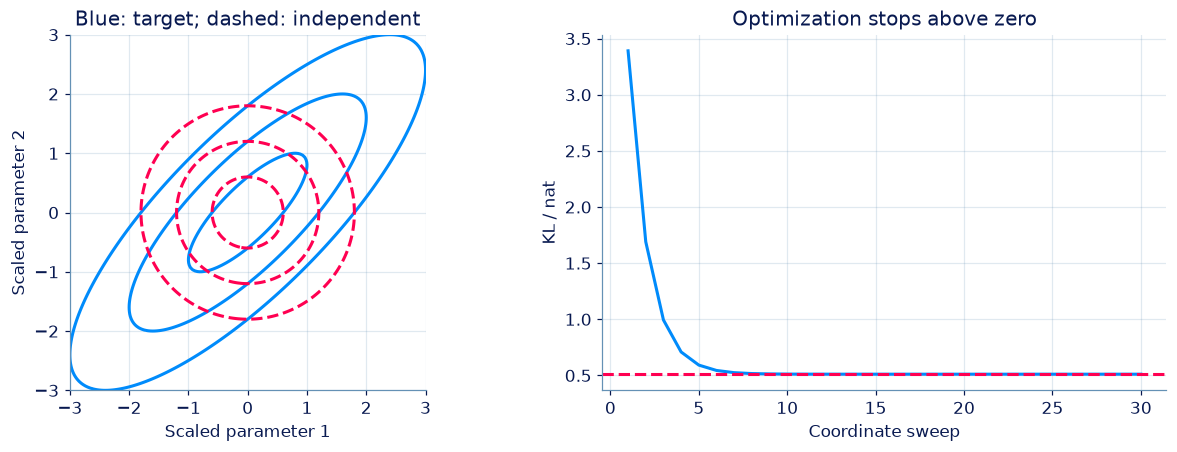

最终均值、方差、KL： [-5.746858278247073e-06, -4.597486622597658e-06] [0.3599999999999999, 0.3599999999999999] 0.5108256237825038


In [4]:
P=precision.tolist();target=[0.,0.];means=[3.,-3.];gaps=[]
for _ in range(30):
    means,variances,kl=mean_field_sweep(P,target,means);gaps.append(kl)
x=np.linspace(-3,3,160);X,Y=np.meshgrid(x,x);points=np.stack([X,Y],axis=-1)
exact=np.einsum('...i,ij,...j->...',points,precision,points);approx=X**2/variances[0]+Y**2/variances[1]
fig,axes=plt.subplots(1,2,figsize=(11,4));axes[0].contour(X,Y,exact,levels=[1,4,9],colors=BLUE);axes[0].contour(X,Y,approx,levels=[1,4,9],colors=PINK,linestyles='--');axes[0].set(xlabel='Scaled parameter 1',ylabel='Scaled parameter 2',title='Blue: target; dashed: independent');axes[0].set_aspect('equal')
axes[1].plot(np.arange(1,31),gaps);axes[1].axhline(-.5*math.log(1-rho*rho),color=PINK,linestyle='--');axes[1].set(xlabel='Coordinate sweep',ylabel='KL / nat',title='Optimization stops above zero');plt.show()
print('最终均值、方差、KL：',means,variances,gaps[-1])

## 结果解释

独立近似无法沿斜向伸展，即使均值已经接近0，KL仍停在正值。ρ=.8时因子方差.36，而目标边缘方差1。本例的独立族配合反向 KL 产生了方差缩小。全协方差高斯族在这个例子中可以精确表示目标。

### 独立核对

用不同于更新公式的联合矩阵（matrix）运算核对KL；在有限状态（state）例中直接计算后验质量与对数比，核对ELBO恒等式。

In [5]:
V=np.diag(variances);m=np.array(means)
reference=.5*(np.trace(precision@V)+m@precision@m-2+np.linalg.slogdet(cov)[1]-np.linalg.slogdet(V)[1])
np.testing.assert_allclose(gaps[-1],reference,atol=1e-12)
assert np.all(np.diff(gaps)<=1e-12)
np.testing.assert_allclose(variances,[.36,.36])
joint=np.array([.1,.3]);q=np.array([.4,.6]);bound,gap=discrete_elbo(np.log(joint).tolist(),q.tolist())
np.testing.assert_allclose(gap,np.sum(q*np.log(q/(joint/joint.sum()))))
assert discrete_elbo([0.,0.],[1.,0.])==(0.,math.log(2))
print('矩阵KL、有限状态恒等式、零概率与逐轮单调性通过。')

矩阵KL、有限状态恒等式、零概率与逐轮单调性通过。


[在本章探索中改变条件](http://127.0.0.1:8000/chapters/09-03-变分推断/explore/)：先预测结果，再比较图形与数值。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：完成一轮均值场坐标更新

目标p=N(μ,P⁻¹)，近似q=q1q2。实现一轮精确坐标更新并计算解析KL。

**函数与代码模板**

```python
def solve(
    precision: list[list[float]],
    target_mean: list[float],
    current_mean: list[float],
) -> tuple[list[float], list[float], float]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `precision` | `list[list[float]]` | 二维高斯目标的对称正定（positive definite）精度矩阵（matrix）P。 | 1 |
| `target_mean` | `list[float]` | 目标均值μ。 | 1 |
| `current_mean` | `list[float]` | 当前两个因子均值。 | 1 |

**返回值**

按以下顺序返回元组：(means, variances, kl)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `means` | `list[float]` | 先更新第一因子、再用新值更新第二因子的均值。 | 1 |
| `variances` | `list[float]` | 独立因子的方差（variance）1/Pii。 | 1 |
| `kl` | `float` | 更新后的KL(q&#124;&#124;p)，单位nat。 | nat |

**计算规则**

m1=μ1−P12(m2−μ2)/P11；再用新m1更新m2=μ2−P21(m1−μ1)/P22。vi=1/Pii；KL=[tr(Pdiag(v))+(m−μ)ᵀP(m−μ)−2−log(det(P)v1v2)]/2。

**约束与边界**

- 二维正定P，特征值（eigenvalue）在[0.05,20]，均值绝对值≤20。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| precision | 二维高斯目标的对称正定（positive definite）精度矩阵（matrix）P。 | [[2.0, -1.0], [-1.0, 2.0]] | 1 |
| target_mean | 目标均值μ。 | [0.0, 0.0] | 1 |
| current_mean | 当前两个因子均值。 | [2.0, 2.0] | 1 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
precision = [[2.0, -1.0], [-1.0, 2.0]]
target_mean = [0.0, 0.0]
current_mean = [2.0, 2.0]

result = solve(precision, target_mean, current_mean)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| means | 先更新第一因子、再用新值更新第二因子的均值。 | [1.0, 0.5] | 1 |
| variances | 独立因子的方差（variance）1/Pii。 | [0.5, 0.5] | 1 |
| kl | 更新后的KL(q||p)，单位nat。 | ≈ 0.893841 | nat |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([1.0, 0.5],
                   [0.5, 0.5],
                   0.8938410362258904)
```

**样例解释**

依次得到均值[1,0.5]、方差[0.5,0.5]；KL=(1.5−log(.75))/2≈0.893841。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：完成一轮均值场坐标更新](http://127.0.0.1:8000/chapters/09-03-%E5%8F%98%E5%88%86%E6%8E%A8%E6%96%AD/practice/?question=p09-gaussian-coordinate)

### 第 2 题 · Python 计算题：直接枚举证据下界

有限状态（state）可以直接相加求证据，用它核对变分恒等式。

**函数与代码模板**

```python
def solve(
    log_joint: list[float],
    probabilities: list[float],
) -> tuple[float, float]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `log_joint` | `list[float]` | 有限隐状态的log p(y,z)，同一顺序。 | 1 |
| `probabilities` | `list[float]` | 候选q(z)的非负质量，和为1。 | 1 |

**返回值**

按以下顺序返回元组：(elbo, gap)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `elbo` | `float` | sum q(log p(y,z)−log q)，0log0按0处理。 | nat |
| `gap` | `float` | logsumexp(log_joint)−ELBO，即KL(q&#124;&#124;后验（posterior）)。 | nat |

**计算规则**

ELBO只对q>0项求和；gap=logsumexp(log_joint)−ELBO；不把概率（probability）为0的项送入log。

**约束与边界**

- 2—10状态；log_joint在[−1000,1000]；q非负且和为1。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| log_joint | 有限隐状态的log p(y,z)，同一顺序。 | [-2.3025850929940455, -1.2039728043259361] | 1 |
| probabilities | 候选q(z)的非负质量，和为1。 | [0.25, 0.75] | 1 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
log_joint = [-2.3025850929940455, -1.2039728043259361]
probabilities = [0.25, 0.75]

result = solve(log_joint, probabilities)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| elbo | sum q(log p(y,z)−log q)，0log0按0处理。 | ≈ -0.9162907 | nat |
| gap | logsumexp(log_joint)−ELBO，即KL(q||后验（posterior）)。 | 0 | nat |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = (-0.9162907318741551, 0.0)
```

**样例解释**

证据为0.4，q恰好等于后验[.25,.75]，所以下界log(.4)、差距0。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：直接枚举证据下界](http://127.0.0.1:8000/chapters/09-03-%E5%8F%98%E5%88%86%E6%8E%A8%E6%96%AD/practice/?question=p09-finite-bound)

### 第 3 题 · 单项选择题：下界中的距离方向

ELBO(q)=Eq[log p(y,z)−log q(z)]。正确恒等式是哪个？

- **A.** logp(y)=ELBO(q)+KL(q||p(z|y))。
- **B.** logp(y)=ELBO(q)−KL(q||p(z|y))。
- **C.** logp(y)=ELBO(q)+KL(p(z|y)||q)。
- **D.** ELBO是任何q下的精确证据。

[作答：下界中的距离方向](http://127.0.0.1:8000/chapters/09-03-%E5%8F%98%E5%88%86%E6%8E%A8%E6%96%AD/practice/?question=p09-kl-direction)

### 第 4 题 · 多项选择题：独立近似丢掉了什么

二维目标协方差（covariance）[[1,ρ],[ρ,1]]，0<|ρ|<1。最优高斯均值场（mean-field approximation）q1q2会怎样？

- **A.** 每因子方差（variance）为1−ρ²。
- **B.** 每因子方差为1。
- **C.** 不能表达非零交叉协方差。
- **D.** 本例方差缩小，足以证明所有变分近似都低估所有函数的不确定性。

[作答：独立近似丢掉了什么](http://127.0.0.1:8000/chapters/09-03-%E5%8F%98%E5%88%86%E6%8E%A8%E6%96%AD/practice/?question=p09-gaussian-variance)

### 第 5 题 · 单项选择题：下界停止上升

二维相关高斯的均值场（mean-field approximation）坐标更新达到稳定值。哪项判断正确？

- **A.** 目标后验（posterior）已变成独立。
- **B.** 优化可能已完成，但近似族仍遗漏相关性。
- **C.** 必须把观测（observation）改成符合近似的数据。
- **D.** 停止上升说明数据来自该模型（model）。

[作答：下界停止上升](http://127.0.0.1:8000/chapters/09-03-%E5%8F%98%E5%88%86%E6%8E%A8%E6%96%AD/practice/?question=p09-optimization-error)

**进一步阅读**

[Blei 等，Variational Inference，v9](https://arxiv.org/html/1601.00670v9)：第2节的下界与坐标更新；本节数值为独立设计的教学小例子。